In [1]:
'''Main'''
import numpy as np
import pandas as pd
import os

'''Data Viz'''
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
import matplotlib as mpl

%matplotlib inline

'''Data Prep'''
from sklearn import preprocessing as pp 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.stats import pearsonr 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold 
from sklearn.metrics import log_loss 
from sklearn.metrics import precision_recall_curve, average_precision_score 
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report 
from statistics import mean, stdev

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 

# Load TCP/UDP Benign and Malicious CIC2023 Flows

In [2]:
# Acquire Data
# Data here has all features
current_path = os.getcwd()

# BENIGN DATA FILES ***************************************
file1='dataset/Benign.csv'
benign = pd.read_csv(file1)
benign['attack'] = 0

# DDOS-VOLUMETRIC ATTACK ***********************************
file2='dataset/TCPFlood.csv'
file3='dataset/UDPFlood.csv'
udp = pd.read_csv(file2)
tcp = pd.read_csv(file3)
udp['attack'] = 1
tcp['attack'] = 1

# DDOS-TRANSPORT PROTOCOL VULNERABILITIES *******************
file4='dataset/ACKFrag.csv'
file5='dataset/SYN.csv'
file6='dataset/RSTFIN.csv'
file7='dataset/PUSHACK.csv'
file8='dataset/UDPFrag.csv'

ack = pd.read_csv(file4)
syn = pd.read_csv(file5)
rst = pd.read_csv(file6)
psh = pd.read_csv(file7)
udp_frag = pd.read_csv(file8)

ack['attack'] = 1
syn['attack'] = 1
rst['attack'] = 1
psh['attack'] = 1
udp_frag['attack'] = 1

# DDOS-APPLICATION PROTOCOL VULNERABILITIES *******************
file91='dataset/HTTPFlood.csv'
file92='dataset/Slowloris.csv'
http = pd.read_csv(file91)
slow = pd.read_csv(file92)
http['attack'] = 1
slow['attack'] = 1
## CONCATE ALL THE RECORDS ************************************
frames = [benign, 
          tcp, udp,
          syn, rst, ack, psh, 
          udp_frag,
          http, slow]

data = pd.concat(frames)
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)

In [4]:
# Size of the data
print("Shape of data: ", data.shape)
# Attack wise size
print("Attack and Benign Records: ", data["attack"].value_counts())

Shape of data:  (388251, 35)
Attack and Benign Records:  attack
1    292282
0     95969
Name: count, dtype: int64


In [5]:
data.columns

Index(['ts', 'srcip', 'dstip', 'srcport', 'dstport', 'proto_type', 'sbytes',
       'dbytes', 'flow_bytes', 'rate', 'srate', 'drate', 'spkts', 'dpkts',
       'ttl', 'iat', 'max_iat', 'min_iat', 'total_duration',
       'N_IN_Conn_P_Src_IP', 'N_IN_Conn_P_Dst_IP', 'avg_pkt_len', 'state_con',
       'state_int', 'state_rst', 'fin_flag_number', 'syn_flag_number',
       'psh_flag_number', 'ack_flag_number', 'urg_flag_number',
       'ece_flag_number', 'cwr_flag_number', 'attack', 'x', 'type'],
      dtype='object')

# Select parameters based on the model i.e. with or without time based features

In [6]:
# Features according to Importance
features =['flow_bytes','srate','drate', 'type',
        'ttl','max_iat', 'total_duration',
        'N_IN_Conn_P_Src_IP', 'N_IN_Conn_P_Dst_IP', 'avg_pkt_len',
        'state_con','state_int', 'state_rst', 
        'fin_flag_number', 'syn_flag_number',
        'psh_flag_number', 'ack_flag_number', 
        #'urg_flag_number','ece_flag_number', 
        #'cwr_flag_number'
          ]
best_features = data[features] 
target_features = data[['attack']]

# Split Dataset into X and Y

In [7]:
# Split of  predictors and response variable
X= best_features
y= target_features

# Use StratifiedKFold with K=10

In [8]:
# Create  classifier object.
rf = RandomForestClassifier(n_estimators = 1, n_jobs=2, random_state=0, max_depth=10)  
n_splits = 10
# Create StratifiedKFold object.
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=1)
accu_stratified = []
conf_matrices = []  # Store confusion matrices
per_class_accuracies = [] 

In [9]:
# Create model with StratifiedKFold   
for train_index, test_index in skf.split(X, y):
    x_train_fold, x_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    rf.fit(x_train_fold, y_train_fold)
    #accu_stratified.append(rf.score(x_test_fold, y_test_fold))

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test_fold,rf.predict(x_test_fold))
    conf_matrices.append(conf_matrix)
    
    # Compute per-class accuracies
    per_class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)
    per_class_accuracies.append(per_class_accuracy)

# Convert lists to numpy arrays for easier manipulation
conf_matrices = np.array(conf_matrices)
per_class_accuracies = np.array(per_class_accuracies)


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: Dat

Accuracy of Attack Records:  [0.95592373 0.96946963 0.96613525 0.96644785 0.96832343 0.97801396
 0.95686152 0.973325   0.95060957 0.97530221]

Median Accuracy of Attack Records: 96.7385641346254 %

Standard Deviation of Attack Records: 0.008969510761189476
Accuracy of Benign Records:  [0.98255158 0.97406596 0.97752155 0.97687149 0.97163679 0.97170521
 0.9736554  0.96547831 0.97680307 0.96770331]

Median Accuracy of Benign Records: 97.38606815382511 %

Standard Deviation of Benign Records: 0.00499412960744845


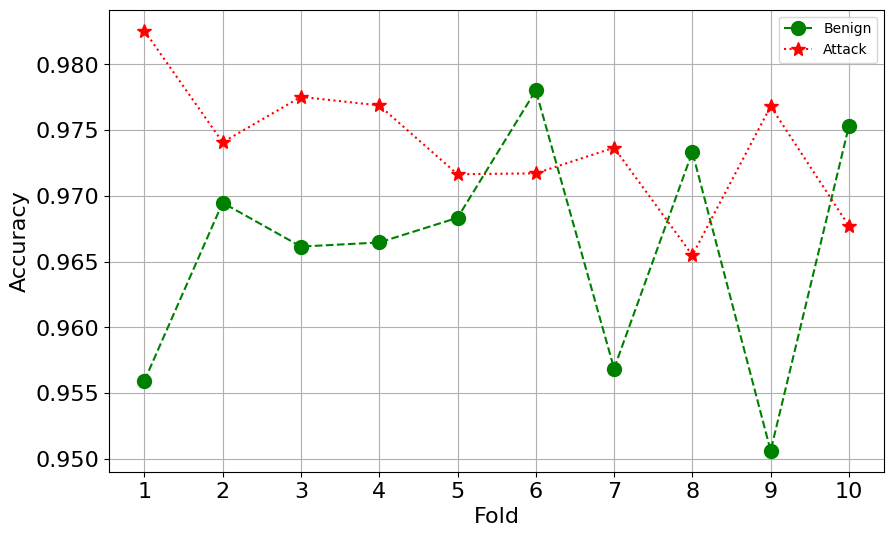

In [10]:
# Plotting per-class accuracies

plt.figure(figsize=(10, 6))
for i, class_accuracy in enumerate(per_class_accuracies.T, 1):
    if(i==1):
        plt.plot(range(1, n_splits + 1), class_accuracy, marker='o', label=f'Benign', color='green',  linestyle='dashed', markersize=10)
        print("Accuracy of Attack Records: ", class_accuracy)
        print('\nMedian Accuracy of Attack Records:', np.median(class_accuracy)*100, '%')
        print('\nStandard Deviation of Attack Records:', stdev(class_accuracy))
    else:
        plt.plot(range(1, n_splits + 1), class_accuracy, marker='*', label=f'Attack', color='red',  linestyle='dotted', markersize=10)  
        print("Accuracy of Benign Records: ", class_accuracy)
        print('\nMedian Accuracy of Benign Records:', np.median(class_accuracy)*100, '%')
        print('\nStandard Deviation of Benign Records:', stdev(class_accuracy))
    
plt.title('')
plt.xlabel('Fold', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.xticks(range(1, n_splits + 1))
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)
plt.legend()
plt.grid(True)
# Save the plot as a PNG file
plt.savefig('StratifiedKFold_5Tree.png', bbox_inches='tight')
plt.show()

# Training model on the whole dataset

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
rf = RandomForestClassifier(n_estimators = 1, n_jobs=2, random_state=0, max_depth=10)
rf.fit(X, y)

C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,1
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Mean Decrease of Accuracy of the Parameters

[np.float64(0.01865326357455026), np.float64(0.013954781917678209), np.float64(0.051862305664453295), np.float64(0.004624473984709812), np.float64(0.011368305313576615), np.float64(0.12952610062836453), np.float64(0.048099261272123835), np.float64(0.05284694600931789), np.float64(0.6342925247063723), np.float64(0.009143034090247361), np.float64(0.00010384205253204589), np.float64(0.01724078110352628), np.float64(3.095625856695245e-05), np.float64(0.00021193305862535967), np.float64(8.612280232337161e-05), np.float64(0.0), np.float64(0.007955367563031857)]


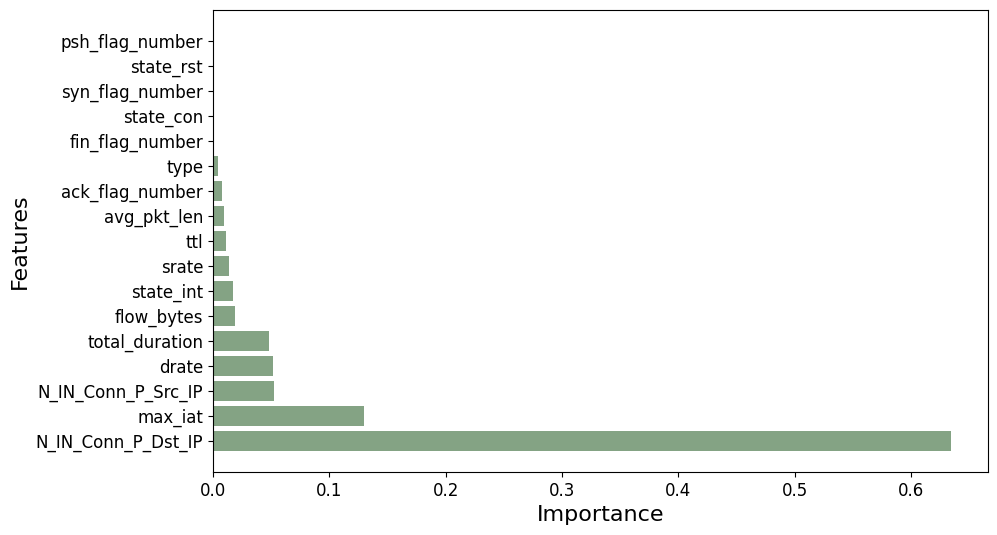

In [12]:
best_features.rename(columns={"N_IN_Conn_P_Src_IP": "N_IN_Conn_Src_IP", "N_IN_Conn_P_Dst_IP": "N_IN_Conn_Dst_IP"})
labels = best_features.columns

importances = list(rf.feature_importances_)
print(importances)
colors = (0.2, # redness
         0.4, # greenness
         0.2, # blueness
         0.6 # transparency
         ) 
# Sort feature importances in descending order
sorted_indices = np.argsort(importances)[::-1]
sorted_list =[importances[i] for i in sorted_indices]
# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title('')
plt.barh(range(X.shape[1]), sorted_list, align="center",color=colors )
plt.yticks(range(X.shape[1]), labels[sorted_indices], fontsize=12)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tick_params(axis='both', which='minor', labelsize=12)
# Save the plot as a PNG file
plt.savefig('Importance.png', bbox_inches='tight')
plt.show()

# Save RF Detector

In [13]:
import pickle as pickle
filename = 'combined_time.sav'
pickle.dump(rf, open(filename, 'wb'))

# Generate Tree

In [14]:
from sklearn import tree
from sklearn.tree import export_text
i_tree = 0
for tree_in_forest in rf.estimators_:
    with open('tree_' + str(i_tree) + '.dot', 'w') as my_file:
        my_file = tree.export_graphviz(tree_in_forest, out_file = my_file)
        r = export_text(tree_in_forest)
        print("TREE ", i_tree)
        print(r)  
    i_tree = i_tree + 1

TREE  0
|--- feature_8 <= 3.50
|   |--- feature_6 <= 1.09
|   |   |--- feature_0 <= 148069.00
|   |   |   |--- feature_0 <= 9070.00
|   |   |   |   |--- feature_1 <= 233.86
|   |   |   |   |   |--- feature_7 <= 1.50
|   |   |   |   |   |   |--- feature_2 <= 21.77
|   |   |   |   |   |   |   |--- feature_5 <= 0.10
|   |   |   |   |   |   |   |   |--- feature_6 <= 0.19
|   |   |   |   |   |   |   |   |   |--- feature_4 <= 47.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- feature_4 >  47.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |--- feature_6 >  0.19
|   |   |   |   |   |   |   |   |   |--- feature_9 <= 63.00
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- feature_9 >  63.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- feature_5 >  0.10
|   |   |   |   |   |   |   |   |--- feature_5 <= 0.14
|   |

# Display (Match-Action) Rules of the RF Tree, acceptable to P4

In [15]:
from io import StringIO
from numbers import Integral

import numpy as np
import pandas
import pickle 
import sklearn
from sklearn import tree 
from sklearn.tree import export_text

from sklearn.tree import _tree

from sklearn.tree import DecisionTreeClassifier

filename = 'combined_time.sav'
rf = pickle.load(open(filename, 'rb'))

i_tree = 0 

global_id = 0

def export_p4(decision_tree):
    tree_ = decision_tree.tree_
    class_names = decision_tree.classes_
    right_child_fmt = "{} {} <= {}\n"
    left_child_fmt = "{} {} >  {}\n"
    truncation_fmt = "{} {}\n"
    feature_names_ = ["{}".format(i) for i in tree_.feature]  
    export_text.report = ""
    max_depth=10
    spacing=3
    decimals=2
    show_weights=False

    if isinstance(decision_tree, DecisionTreeClassifier):
        value_fmt = "{}{} weights: {}\n"
        if not show_weights:
            value_fmt = "{}{}{}\n"
    else:
        value_fmt = "{}{} value: {}\n"

    def _add_leaf(value, class_name, indent, prevfeature, result, depth, previous_id):
        global global_id
        global i_tree 
        current_id = global_id

        val = ''
        is_classification = isinstance(decision_tree,
                                       DecisionTreeClassifier)
        if show_weights or not is_classification:
            val = ["{1:.{0}f}, ".format(decimals, v) for v in value]
            val = '['+''.join(val)[:-2]+']'
        if is_classification:
            val += ' class: ' + str(class_name)
        export_text.report += value_fmt.format(indent, '', val)
        print("table_add MyIngress.level_", depth, " ", "MyIngress.SetClass"," ", previous_id," ",prevfeature," ", result," ", "=>"," ", current_id, " ", int(float(class_name)), sep="")

    def print_tree_recurse(node, depth, prevfeature, result, previous_id):
        indent = ("|" + (" " * spacing)) * depth
        indent = indent[:-spacing] + "-" * spacing
        global global_id
        global i_tree 
        global_id = global_id + 1
        current_id = global_id

        value = None
        if tree_.n_outputs == 1:
            value = tree_.value[node][0]
        else:
            value = tree_.value[node].T[0]
        class_name = np.argmax(value)

        if (tree_.n_classes[0] != 1 and
                tree_.n_outputs == 1):
            class_name = class_names[class_name]

        if depth <= max_depth+1:
            info_fmt = ""
            info_fmt_left = info_fmt
            info_fmt_right = info_fmt

            if tree_.feature[node] != _tree.TREE_UNDEFINED:
                name = feature_names_[node]
                threshold = tree_.threshold[node]
                threshold = "{1:.{0}f}".format(decimals, threshold)
                export_text.report += right_child_fmt.format(indent,
                                                             name,
                                                             threshold)
                export_text.report += info_fmt_left
                print("table_add MyIngress.level_", depth, " MyIngress.CheckFeature ", previous_id, " ", prevfeature, " ", result, " ", "=>", " ", current_id, " ", name," ", int(float(threshold)), sep='')

                print_tree_recurse(tree_.children_left[node], depth+1, name, 1, current_id)

                export_text.report += left_child_fmt.format(indent,
                                                            name,
                                                            threshold)
                export_text.report += info_fmt_right
           #     print("level", depth, "checkfeature", prevfeature, result, "=>", name, threshold)
 

                print_tree_recurse(tree_.children_right[node], depth+1, name, 0, current_id)
            else:  # leaf
                _add_leaf(value, class_name, indent, prevfeature, result, depth, previous_id)
        else:
            subtree_depth = _compute_depth(tree_, node)
            if subtree_depth == 1:
                _add_leaf(value, class_name, indent, prevfeature, result, depth, previous_id)
            else:
                trunc_report = 'truncated branch of depth %d' % subtree_depth
                export_text.report += truncation_fmt.format(indent,
                                                            trunc_report)

    print_tree_recurse(0, 1, 0, 1, global_id)


for tree_in_forest in rf.estimators_:
  #r = export_text(tree_in_forest)
  #print(r)
  global i_tree

  i_tree = i_tree + 1
  export_p4(tree_in_forest)

table_add MyIngress.level_1 MyIngress.CheckFeature 0 0 1 => 1 8 3
table_add MyIngress.level_2 MyIngress.CheckFeature 1 8 1 => 2 6 1
table_add MyIngress.level_3 MyIngress.CheckFeature 2 6 1 => 3 0 148069
table_add MyIngress.level_4 MyIngress.CheckFeature 3 0 1 => 4 0 9070
table_add MyIngress.level_5 MyIngress.CheckFeature 4 0 1 => 5 1 233
table_add MyIngress.level_6 MyIngress.CheckFeature 5 1 1 => 6 7 1
table_add MyIngress.level_7 MyIngress.CheckFeature 6 7 1 => 7 2 21
table_add MyIngress.level_8 MyIngress.CheckFeature 7 2 1 => 8 5 0
table_add MyIngress.level_9 MyIngress.CheckFeature 8 5 1 => 9 6 0
table_add MyIngress.level_10 MyIngress.CheckFeature 9 6 1 => 10 4 47
table_add MyIngress.level_11 MyIngress.SetClass 10 4 1 => 11 1
table_add MyIngress.level_11 MyIngress.SetClass 10 4 0 => 12 1
table_add MyIngress.level_10 MyIngress.CheckFeature 9 6 0 => 13 9 63
table_add MyIngress.level_11 MyIngress.SetClass 13 9 1 => 14 1
table_add MyIngress.level_11 MyIngress.SetClass 13 9 0 => 15 0
table

# Now predicting about separatly processes data

In [16]:
current_path = os.getcwd()

file1='dataset/Benign_Test_1.csv'
benign = pd.read_csv(file1)
file2='dataset/RSTFIN_Test.csv'
rst = pd.read_csv(file2)
file3='dataset/TCPFlood.csv'
tcp = pd.read_csv(file3)
file4='dataset/SYN_Test.csv'
syn = pd.read_csv(file4)
file5='dataset/UDPFlood_Test.csv'
udp = pd.read_csv(file5)
file6='dataset/UDPFrag_Test.csv'
udp_frag = pd.read_csv(file6)
file7='dataset/HTTPFlood_Test.csv'
http = pd.read_csv(file7)
file8='dataset/SlowLoris_Test.csv'
slow = pd.read_csv(file8)
file9='dataset/PUSHACK_Test.csv'
psh = pd.read_csv(file9)
file10='dataset/ACKFrag_Test.csv'
ack = pd.read_csv(file10)

benign['attack'] = 0
rst['attack'] = 1
tcp['attack'] = 1
syn['attack'] = 1
udp['attack'] = 1
ack['attack'] = 1
psh['attack'] = 1
udp_frag['attack'] = 1
http['attack'] = 1
slow['attack'] = 1

# Test Benign

In [17]:
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_fscore_support

data = pd.concat([benign])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:", 1- sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 0.9171075837742504
Precision:  [1. 0.]
Recall:  [0.91710758 0.        ]
F1-score:  [0.95676173 0.        ]
Support:  [1134    0]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test SYN Flood

In [18]:
data = pd.concat([syn])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy: ", sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy:  0.9982509142948004
Precision:  [0. 1.]
Recall:  [0.         0.99825091]
F1-score:  [0.         0.99912469]
Support:  [    0 12578]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# TCP PUSH ACK

In [19]:
data = pd.concat([psh])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy: ", sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy:  0.9998476480670349
Precision:  [0. 1.]
Recall:  [0.         0.99984765]
F1-score:  [0.         0.99992382]
Support:  [    0 26255]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# TCP ACK Fragmentation

In [20]:
data = pd.concat([ack])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy: ", sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy:  0.9771729587357331
Precision:  [0. 1.]
Recall:  [0.         0.97717296]
F1-score:  [0.         0.98845471]
Support:  [   0 1139]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test TCP DoS

In [21]:
data = pd.concat([tcp])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:", sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 0.9995152802142
Precision:  [0. 1.]
Recall:  [0.         0.99951528]
F1-score:  [0.         0.99975758]
Support:  [    0 43324]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test RST FIN Flood

In [22]:
data = pd.concat([rst])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy: ", sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy:  0.9994142259414226
Precision:  [0. 1.]
Recall:  [0.         0.99941423]
F1-score:  [0.         0.99970703]
Support:  [    0 11950]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test UDP Flood

In [23]:
data = pd.concat([udp])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:",  sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 0.9961629959327757
Precision:  [0. 1.]
Recall:  [0.       0.996163]
F1-score:  [0.         0.99807781]
Support:  [    0 13031]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test HTTP Flood

In [24]:
data = pd.concat([http])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:",  sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 0.9321148825065274
Precision:  [0. 1.]
Recall:  [0.         0.93211488]
F1-score:  [0.         0.96486486]
Support:  [   0 2298]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Test UDP Frag

In [25]:
data = pd.concat([udp_frag])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:",  sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 1.0
Precision:  [1.]
Recall:  [1.]
F1-score:  [1.]
Support:  [526]


# Test Slowloris

In [26]:
data = pd.concat([slow])
data['type'] = data['proto_type'].apply(lambda x: 0 if x > 6 else 1)
best_features = data[features]
target_features = data[['attack']]
prediction = rf.predict(best_features)
print("Accuracy:",  sum(prediction)/len(prediction))
# Calculate precision, recall, F1-score, and support
precision, recall, fscore, support = precision_recall_fscore_support(target_features, prediction)
# Print the results for each class
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-score: ", fscore)
print("Support: ", support)

Accuracy: 0.9359083191850595
Precision:  [0. 1.]
Recall:  [0.         0.93590832]
F1-score:  [0.         0.96689323]
Support:  [   0 4712]


C:\Users\MRAdmin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
